# Setup

This notebook requires:
- [DeepFurniture Dataset](https://huggingface.co/datasets/byliu/DeepFurniture#using-the-dataset) downloaded and uncompressed to `./data/DeepFurniture/uncompressed_data`
- Repository [Depth-Anything-V2](https://github.com/DepthAnything/Depth-Anything-V2?tab=readme-ov-file#usage) cloned at `./DepthAnythingV2`
- Depth-Anything-V2 [pre-trained models](https://github.com/DepthAnything/Depth-Anything-V2?tab=readme-ov-file#pre-trained-models) downloaded to `./DepthAnythingV2/checkpoints`

In [ ]:
import time
import random

import cv2
import numpy as np
import pandas as pd

import wandb

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T
import torch.nn.functional as F

from tqdm import tqdm
from pathlib import Path

import h5py

from DepthAnythingV2.depth_anything_v2.dpt import DepthAnythingV2

# reference to cloned repository
from data.DeepFurniture.deepfurniture import DeepFurnitureDataset


DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 

In [ ]:
wandb.login()

# Preprocessing & Dataset

In [ ]:
base_dataset = DeepFurnitureDataset("./data/DeepFurniture/uncompressed_data")

## Data Analysis

In [ ]:
import csv

with open('depth_statistics.csv', mode='w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=['image_id', 'min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range'])
    writer.writeheader()

    for idx, sample in enumerate(tqdm(base_dataset)):
        try:
            depth_array = np.array(sample['depth']).flatten()
            image_id = sample['scene_id']

            writer.writerow({
                'image_id': image_id,
                'min_depth': np.min(depth_array),
                'max_depth': np.max(depth_array),
                'mean_depth': np.mean(depth_array),
                'std_depth': np.std(depth_array),
                'median_depth': np.median(depth_array),
                'depth_range': np.max(depth_array) - np.min(depth_array)
            })

        except Exception as e:
            print(f"Error processing sample {idx}: {e}")

In [ ]:
df = pd.read_csv('depth_statistics.csv')
df.head()

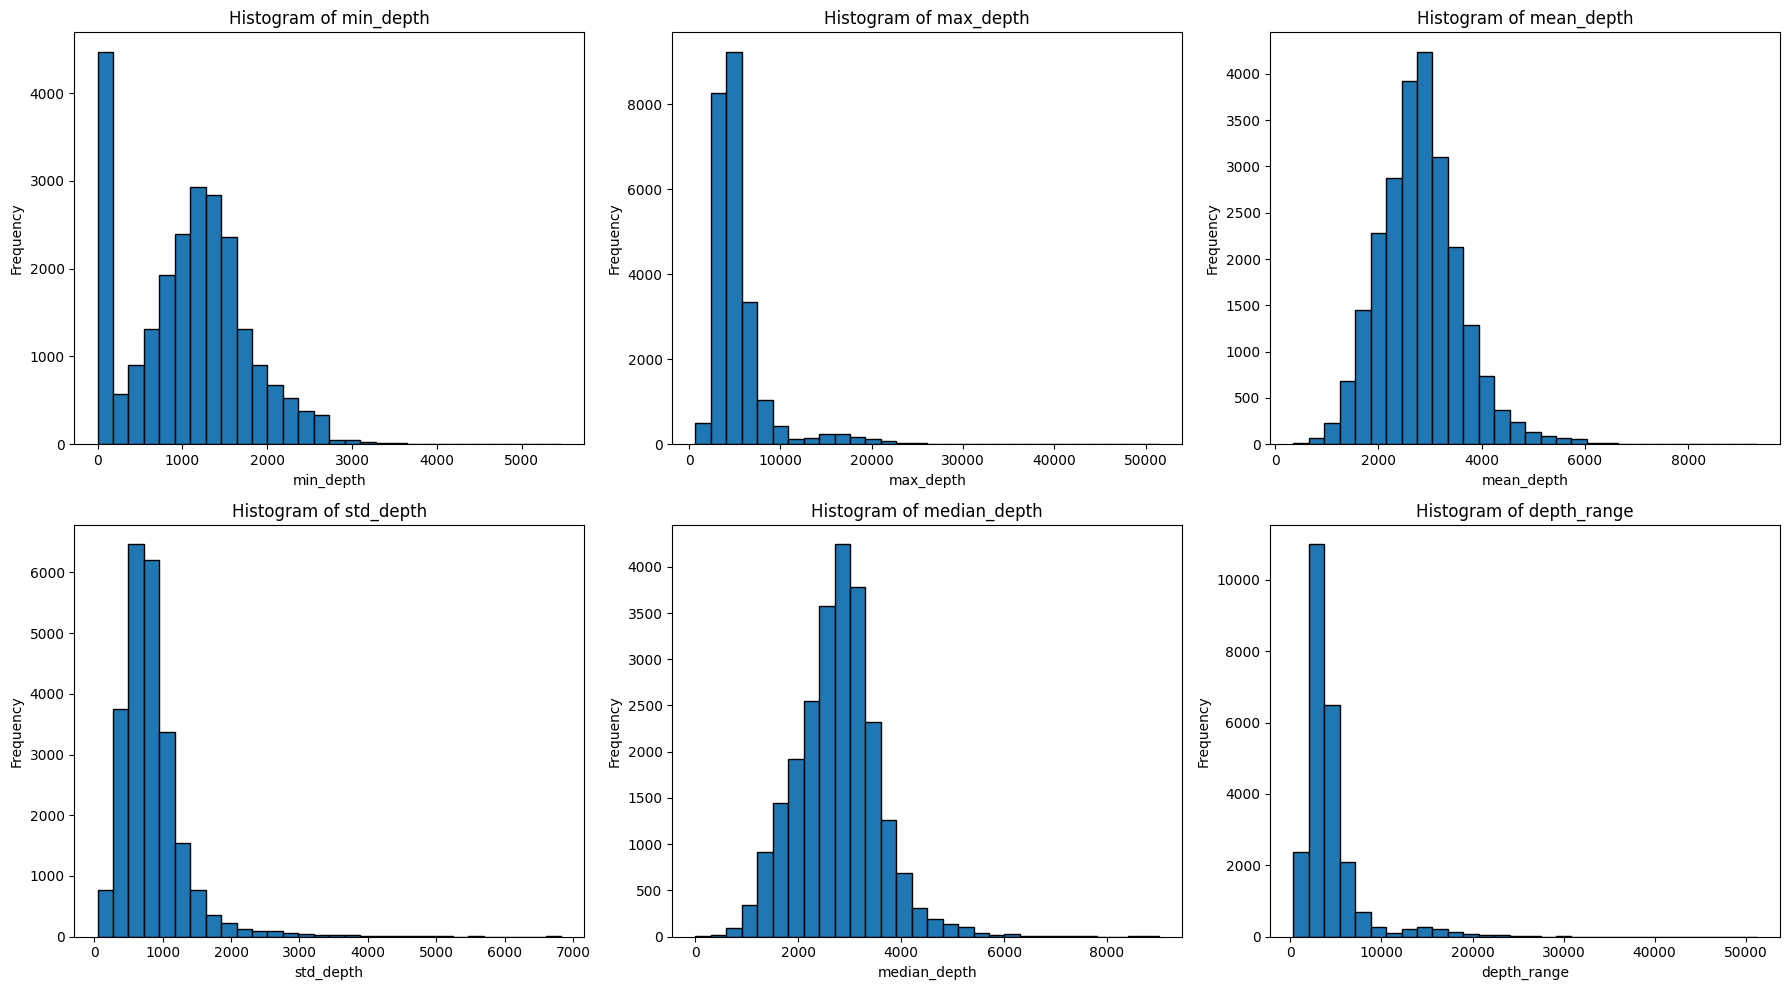

In [27]:
# List of depth statistic columns to plot
depth_metrics = ['min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range']

# Set up the figure and axes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# Generate histograms for each metric
for idx, metric in enumerate(depth_metrics):
    axes[idx].hist(df[metric], bins=30, edgecolor='black')
    axes[idx].set_title(f'Histogram of {metric}')
    axes[idx].set_xlabel(metric)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\timon\AppData\Local\Temp\ipykernel_45348\4082865173.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[metric] for metric in depth_metrics], labels=depth_metrics, vert=True)


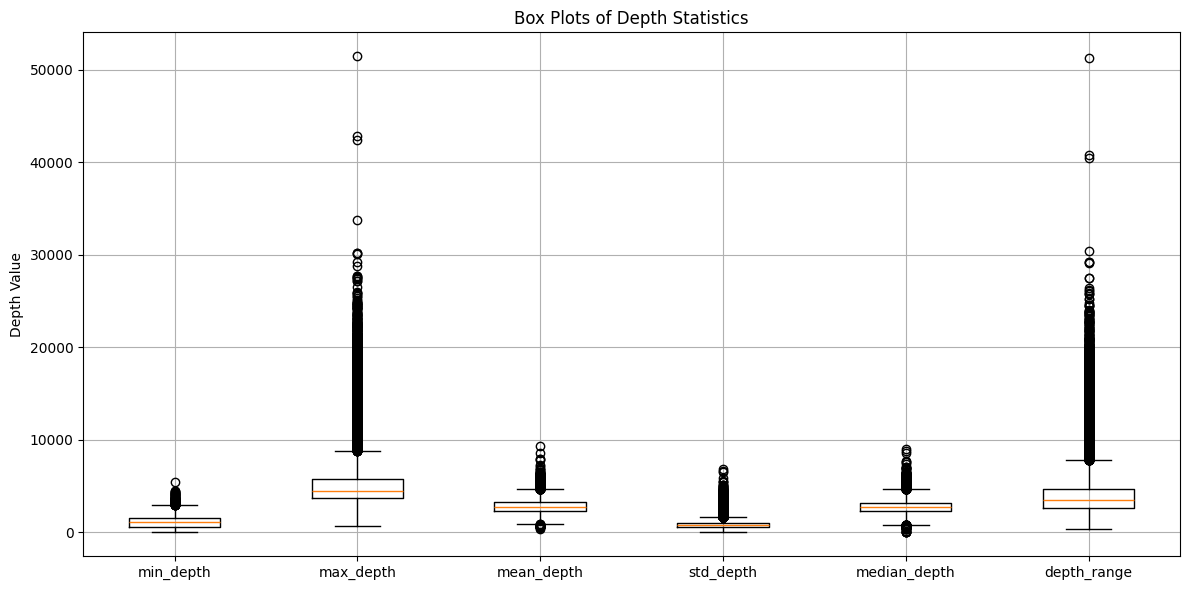

In [28]:
# List of depth metric columns
depth_metrics = ['min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range']

# Create a boxplot
plt.figure(figsize=(12, 6))
plt.boxplot([df[metric] for metric in depth_metrics], labels=depth_metrics, vert=True)

# Add titles and labels
plt.title('Box Plots of Depth Statistics')
plt.ylabel('Depth Value')
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
df.sort_values(by='max_depth', ascending=False).head()

,image_id,min_depth,max_depth,mean_depth,std_depth,median_depth,depth_range
20925,L3D187S8ENDIY7YXAQUG5TL4UU23P3XY888,231,51469,2774.068019,4465.006412,2485.0,51238
12571,L3D187I733ATIUPFR7ORFW3P3WU888,2398,42890,3997.166321,872.284065,3807.0,40492
12591,L3D187I73N7FQUPFR7ORFW3P3XW888,1562,42398,4059.069472,1130.516017,3673.0,40836
22135,L3D197I644S5QUG5TL463O3P3W4888,3418,33807,8540.212867,3800.445082,8841.0,30389
12809,L3D187I7O3JHIUPFX6U5UV3P3XQ888,1117,30233,4316.945390,2642.001092,4092.0,29116


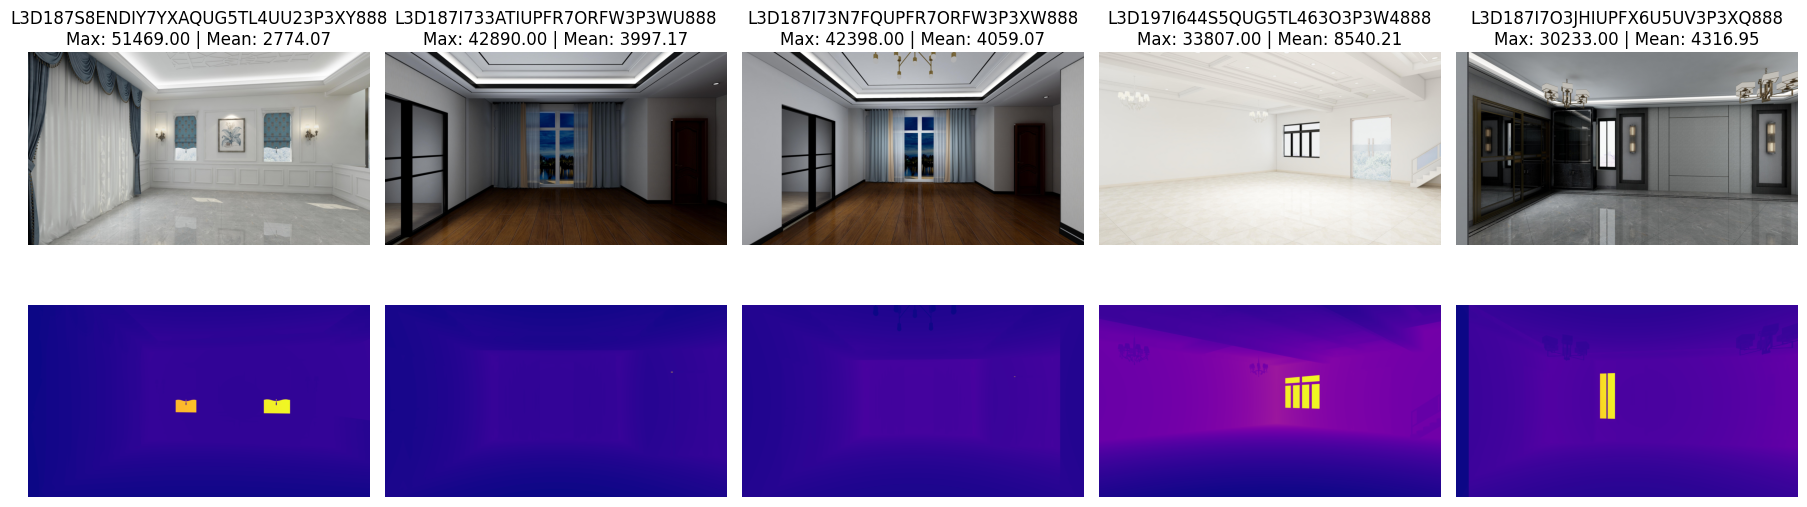

In [30]:
import os

from PIL import Image


scenes_root = r'C:\\Users\\timon\\git\\HSLU.DSPRO2.Beyond2D\\data\\DeepFurniture\\uncompressed_data\\scenes'

# Sort by max_depth in descending order and get top 5 entries
top_images = df.sort_values(by='max_depth', ascending=False).head(5)

# Create a 2-row subplot: top = RGB, bottom = Depth
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 6))

for i, row in enumerate(top_images.itertuples(), start=0):
    image_id = row.image_id
    folder_path = os.path.join(scenes_root, str(image_id))
    rgb_path = os.path.join(folder_path, 'image.jpg')
    depth_path = os.path.join(folder_path, 'depth.png')

    # Load and plot RGB image
    if os.path.exists(rgb_path):
        rgb_img = Image.open(rgb_path)
        axes[0, i].imshow(rgb_img)
        axes[0, i].set_title(f'{image_id}\nMax: {row.max_depth:.2f} | Mean: {row.mean_depth:.2f}')
        axes[0, i].axis('off')
    else:
        axes[0, i].set_visible(False)
        print(f"RGB image not found: {rgb_path}")

    # Load and plot depth image (as grayscale)
    if os.path.exists(depth_path):
        depth_img = Image.open(depth_path)
        axes[1, i].imshow(depth_img, cmap='plasma')
        axes[1, i].axis('off')
    else:
        axes[1, i].set_visible(False)
        print(f"Depth image not found: {depth_path}")

plt.tight_layout()
plt.show()

C:\Users\timon\AppData\Local\Temp\ipykernel_45348\1459326179.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_filtered[metric] for metric in depth_metrics], labels=depth_metrics, vert=True)


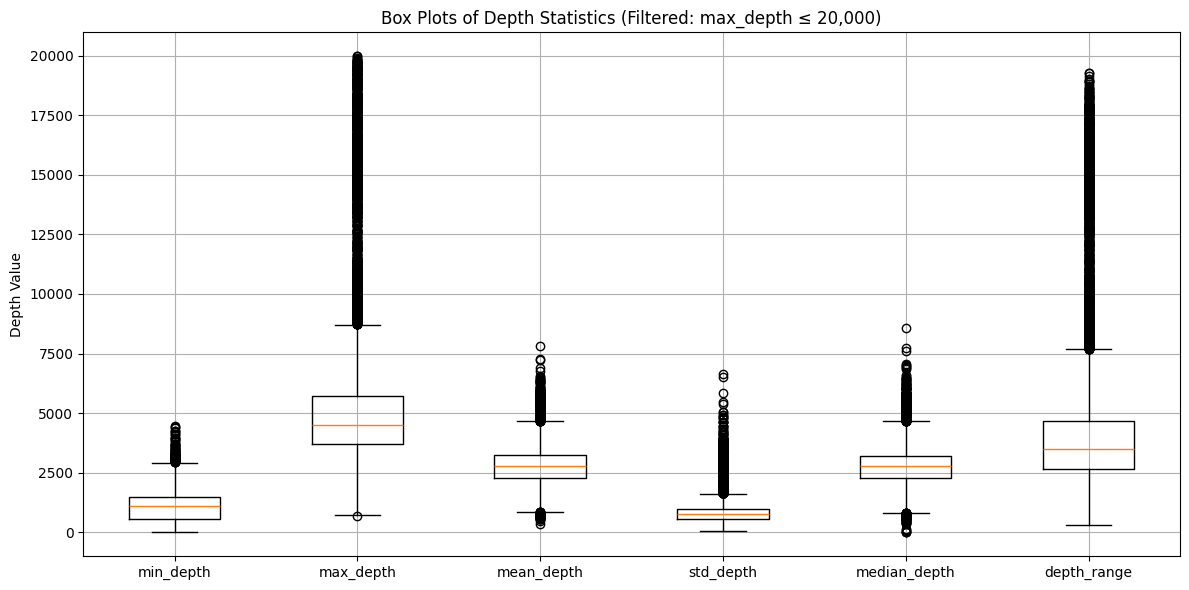

In [31]:
# Filter out entries with max_depth > 20000
df_filtered = df[df['max_depth'] <= 20000]

# List of depth metric columns to plot
depth_metrics = ['min_depth', 'max_depth', 'mean_depth', 'std_depth', 'median_depth', 'depth_range']

# Create boxplot
plt.figure(figsize=(12, 6))
plt.boxplot([df_filtered[metric] for metric in depth_metrics], labels=depth_metrics, vert=True)

# Add titles and labels
plt.title('Box Plots of Depth Statistics (Filtered: max_depth ≤ 20,000)')
plt.ylabel('Depth Value')
plt.grid(True)

plt.tight_layout()
plt.show()

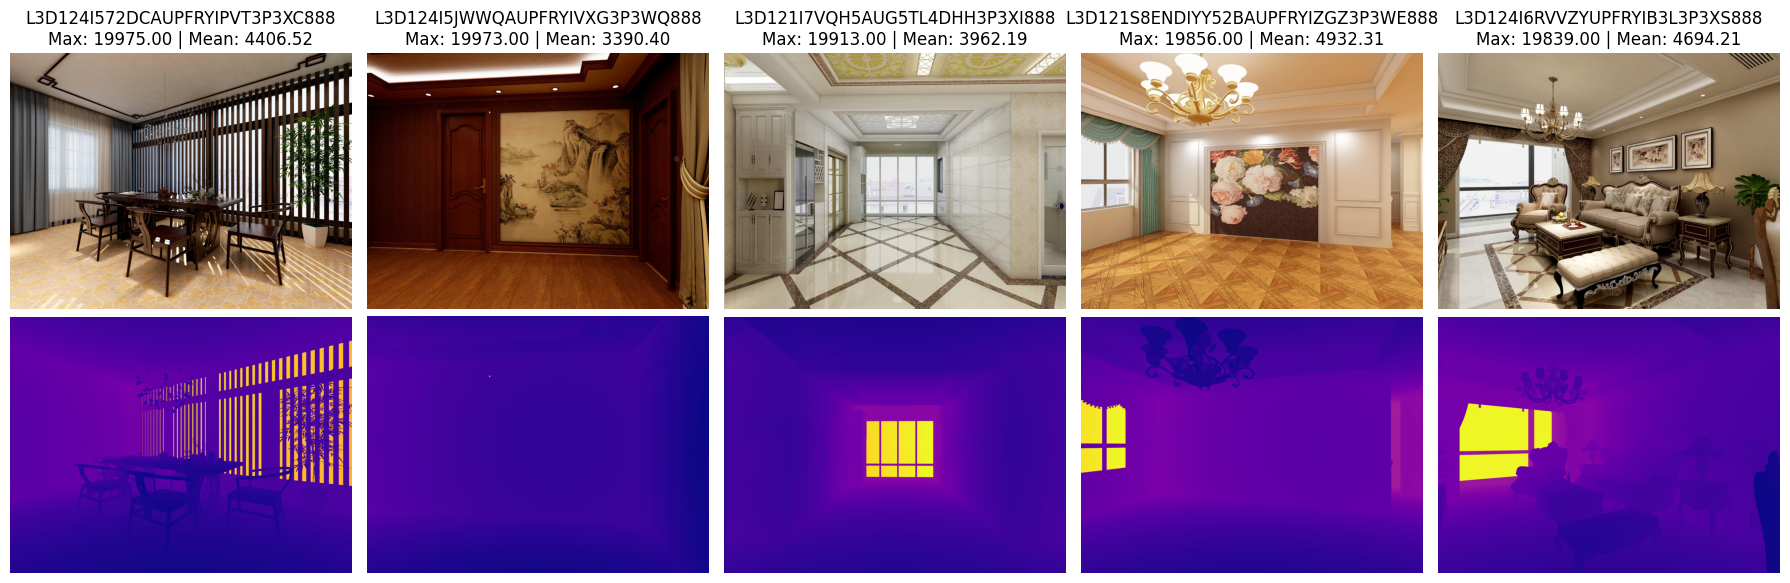

In [32]:
import os

from PIL import Image


scenes_root = r'C:\\Users\\timon\\git\\HSLU.DSPRO2.Beyond2D\\data\\DeepFurniture\\uncompressed_data\\scenes'

# Sort by max_depth in descending order and get top 5 entries
top_images = df_filtered.sort_values(by='max_depth', ascending=False).head(5)

# Create a 2-row subplot: top = RGB, bottom = Depth
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 6))

for i, row in enumerate(top_images.itertuples(), start=0):
    image_id = row.image_id
    folder_path = os.path.join(scenes_root, str(image_id))
    rgb_path = os.path.join(folder_path, 'image.jpg')
    depth_path = os.path.join(folder_path, 'depth.png')

    # Load and plot RGB image
    if os.path.exists(rgb_path):
        rgb_img = Image.open(rgb_path)
        axes[0, i].imshow(rgb_img)
        axes[0, i].set_title(f'{image_id}\nMax: {row.max_depth:.2f} | Mean: {row.mean_depth:.2f}')
        axes[0, i].axis('off')
    else:
        axes[0, i].set_visible(False)
        print(f"RGB image not found: {rgb_path}")

    # Load and plot depth image (as grayscale)
    if os.path.exists(depth_path):
        depth_img = Image.open(depth_path)
        axes[1, i].imshow(depth_img, cmap='plasma')
        axes[1, i].axis('off')
    else:
        axes[1, i].set_visible(False)
        print(f"Depth image not found: {depth_path}")

plt.tight_layout()
plt.show()

## Data Split

In [ ]:
class HDF5Dataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(self.h5_path, 'r') as f:
            self.keys = list(f.keys())

    def __getitem__(self, index):
        if not hasattr(self, 'file') or self.file is None:
            self.file = h5py.File(self.h5_path, 'r')

        grp = self.file[self.keys[index]]
        image = torch.tensor(grp["image"][:])
        depth = torch.tensor(grp["depth"][:])
        return {"image": image, "depth": depth}

    def __len__(self):
        return len(self.keys)

In [ ]:
def collate_fn(batch):
    return [item for item in batch if item is not None]

In [ ]:
def preprocess_dataset_hdf5(dataset, split, image_size=(392, 392), max_depth_threshold=20000):
    transform_image = T.Compose([
        T.Resize(image_size),
        T.ToTensor(),
        T.Normalize(mean=[0.5] * 3, std=[0.5] * 3)
    ])

    transform_depth = T.Compose([
        T.Resize(image_size),
        T.ToTensor()
    ])

    h5_path = f"processed_{split}_dataset_scaled_absolute_depths_max_20.h5"
    with h5py.File(h5_path, "w") as h5f:
        idx = 0
        for data in tqdm(dataset, desc=f"Preprocessing {split}"):
            try:
                if not data['image'] or not data['depth']:
                    continue

                # Convert depth to tensor early to compute max
                depth = transform_depth(data['depth'])  # Shape: (1, H, W)
                max_depth = depth.max().item()  # Get the max depth value

                if max_depth > max_depth_threshold:
                    continue  # Skip outliers

                # Scale depth: convert from raw units (e.g., mm) to meters (0–20 range)
                scaled_depth = depth / 1000.0

                image = transform_image(data['image'])

                grp = h5f.create_group(f"sample_{idx}")
                grp.create_dataset("image", data=image.numpy(), compression="gzip")
                grp.create_dataset("depth", data=scaled_depth.numpy(), compression="gzip")

                idx += 1

            except Exception as e:
                print(f"Skipping corrupted sample: {e}")
                continue

    print(f"Saved HDF5 to: {h5_path}")


In [ ]:
RUN_PREPROCESSING = False

if RUN_PREPROCESSING:
    # Split indices
    num_samples = len(base_dataset)
    indices = list(range(num_samples))
    random.shuffle(indices)

    train_split = int(0.8 * num_samples)
    val_split = int(0.9 * num_samples)

    train_indices = indices[:train_split]
    val_indices = indices[train_split:val_split]
    test_indices = indices[val_split:]

    # Create subsets
    train_subset = Subset(base_dataset, train_indices)
    val_subset = Subset(base_dataset, val_indices)
    test_subset = Subset(base_dataset, test_indices)

    # Wrap subsets with image/depth transformations
    preprocess_dataset_hdf5(train_subset, 'train')
    preprocess_dataset_hdf5(val_subset, 'val')
    preprocess_dataset_hdf5(test_subset, 'test')



In [ ]:
train_dataset = HDF5Dataset("data/DeepFurniture/pytorch/processed_train_dataset_original_depths.h5")
val_dataset = HDF5Dataset("data/DeepFurniture/pytorch/processed_val_dataset_original_depths.h5")
test_dataset = HDF5Dataset("data/DeepFurniture/pytorch/processed_test_dataset_original_depths.h5")

# Model

In [ ]:
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vits' # or 'vits', 'vitb', 'vitg'

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(f'DepthAnythingV2/checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
model = model.to(DEVICE).eval()

# Training

In [ ]:
def scale_invariant_loss(pred, target):
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    d = torch.log(pred + 1e-6) - torch.log(target + 1e-6)
    return torch.sqrt((d ** 2).mean() - 0.5 * (d.mean()) ** 2)


def berhu_loss(pred, target):
    diff = torch.abs(pred - target)
    c = 0.2 * torch.max(diff).item()
    mask = diff <= c
    l1 = diff[mask]
    l2 = (diff[~mask] ** 2 + c ** 2) / (2 * c)
    return torch.cat([l1, l2]).mean()


In [ ]:
def compute_absrel(pred, gt, eps=1e-6):
    valid = gt > eps
    return (torch.abs(pred[valid] - gt[valid]) / gt[valid]).mean().item()

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

num_epochs = 20
run_name = f'depthanything-{encoder}-{time.strftime("%Y%m%d-%H%M%S")}'

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
model.to(DEVICE)

wandb.init(project="hslu-dspro2-beyond2d", name=run_name, config={
    "epochs": num_epochs,
    "batch_size": train_loader.batch_size,
    "lr": optimizer.param_groups[0]["lr"],
    "encoder": encoder,
})

best_val_absrel = float("inf")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    total_absrel_train = 0.0
    total_delta1_train = 0.0
    start_time = time.time()

    print(f"\n🚀 Starting Epoch {epoch+1}/{num_epochs}")
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)

    for batch in progress_bar:
        images = torch.stack([b["image"] for b in batch]).to(DEVICE)
        depths = torch.stack([b["depth"].squeeze(0) for b in batch]).to(DEVICE)

        pred = model(images)

        loss = berhu_loss(pred, depths)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        absrel = compute_absrel(pred, depths)
        total_absrel_train += absrel

        ratio = torch.max(pred / depths.clamp(min=1e-6), depths / pred.clamp(min=1e-6))
        delta1 = (ratio < 1.25).float().mean().item()
        total_delta1_train += delta1

        progress_bar.set_postfix(loss=loss.item(), absRel=absrel, delta1=delta1)

    avg_loss = epoch_loss / len(train_loader)
    avg_absrel_train = total_absrel_train / len(train_loader)
    avg_delta1_train = total_delta1_train / len(train_loader)
    elapsed = time.time() - start_time
    print(f"✅ Epoch {epoch+1} | Loss: {avg_loss:.4f} | absRel: {avg_absrel_train:.4f} | delta1: {avg_delta1_train:.4f} | Time: {elapsed:.2f}s")

    # Validation
    model.eval()
    val_loss = 0.0
    total_absrel_val = 0.0
    total_delta1_val = 0.0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Validation", leave=False)
        for batch in val_bar:
            images = torch.stack([b["image"] for b in batch]).to(DEVICE)
            depths = torch.stack([b["depth"].squeeze(0) for b in batch]).to(DEVICE)

            pred = model(images)
            loss = F.l1_loss(pred, depths)
            val_loss += loss.item()

            absrel = compute_absrel(pred, depths)
            ratio = torch.max(pred / depths.clamp(min=1e-6), depths / pred.clamp(min=1e-6))
            delta1 = (ratio < 1.25).float().mean().item()

            total_absrel_val += absrel
            total_delta1_val += delta1

            val_bar.set_postfix(loss=loss.item(), absRel=absrel, delta1=delta1)

    avg_val_loss = val_loss / len(val_loader)
    avg_absrel_val = total_absrel_val / len(val_loader)
    avg_delta1_val = total_delta1_val / len(val_loader)
    print(f"🔍 Validation | Loss: {avg_val_loss:.4f} | absRel: {avg_absrel_val:.4f} | delta1: {avg_delta1_val:.4f}")

    scheduler.step(avg_val_loss)

    wandb.log({
        "train_loss": avg_loss,
        "train_absRel": avg_absrel_train,
        "train_delta1": avg_delta1_train,
        "val_loss": avg_val_loss,
        "val_absRel": avg_absrel_val,
        "val_delta1": avg_delta1_val,
        "epoch": epoch + 1
    })

    if avg_absrel_val < best_val_absrel:
        best_val_absrel = avg_absrel_val
        
    checkpoint_path = Path(f"model_epoch_{epoch}.pth")
    torch.save(model.state_dict(), checkpoint_path)
    print(f"💾 Model saved with absRel={avg_absrel_val:.4f}")

    # Log model as artifact
    artifact = wandb.Artifact(name=f"model-epoch-{epoch+1}", type="model")
    artifact.add_file(str(checkpoint_path))
    wandb.log_artifact(artifact)


wandb.finish()


# Evaluation

In [ ]:
import gc

# del model, train_loader, val_loader, optimizer

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
encoder = 'vits'

In [ ]:
pretrained_model = DepthAnythingV2(**model_configs[encoder])
pretrained_model.load_state_dict(torch.load(f'DepthAnythingV2/checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
pretrained_model = pretrained_model.to(DEVICE).eval()

In [ ]:
finetuned_model = DepthAnythingV2(**model_configs[encoder])
finetuned_model.load_state_dict(torch.load(f'DepthAnythingV2/checkpoints/model_original_depth_berhu.pth', map_location='cpu'))
finetuned_model = finetuned_model.to(DEVICE).eval()

In [ ]:
def compute_depth_anything(model, image):
    img_rgb = np.array(image)
    
    # Convert to BGR format for OpenCV
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    
    with torch.no_grad():
        depth_map = model.infer_image(img_bgr)
    
    return depth_map

In [ ]:
def convert_tensor_image(image):
    # Convert torch.Tensor to NumPy array if needed
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()  # CxHxW → HxWxC
        image = (image * 255).astype(np.uint8)  # Rescale if image was normalized

    # Convert to BGR format for OpenCV
    return cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

In [ ]:
def compute_depth_anything(model, image):
    img_bgr = convert_tensor_image(image)

    with torch.no_grad():
        depth_map = model.infer_image(img_bgr)

    return depth_map

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
image = None
depth = None

for scene in test_loader:
    image = scene[0]['image']  # Assuming batch size is 1
    depth = scene[0]['depth']

    output_pretrained = compute_depth_anything(pretrained_model, image)
    output_finetuned = compute_depth_anything(finetuned_model, image)
    break  # Remove this line if you want to run through the full test set

In [ ]:
image = convert_tensor_image(image)
depth = convert_tensor_image(depth)

fig, axes = plt.subplots(1, 4, figsize=(16, 8))

axes[0].set_title('RGB Image', fontsize=14)
axes[0].imshow(image)

axes[1].set_title('Dataset Depth', fontsize=14)
axes[1].imshow(depth)

axes[2].set_title('DepthAnythingV2 Pretrained', fontsize=14)
axes[2].imshow(output_pretrained)

axes[3].set_title('DepthAnythingV2 Finetuned', fontsize=14)
axes[3].imshow(output_finetuned)